# RoPE旋转位置嵌入

根据上一章我们知道, 当前的架构并不能处理涉及 token 位置的任务, 换句话说就是 `Q/K` 不带位置信息, 于是我们需要给其加上位置编码 `Positional Embedding`, 以此让模型学到位置信息.

什么是位置编码? 它的目标是让模型感知 token 的位置以及 token 之间的位置关系.

在 Attention Is All You Need 原论文中实际上用的是正余弦位置编码的方案, 而在现代实践中更加常用和主流的方案是RoPE旋转位置编码[1], 所以我们主要实现后者.

明确了当前架构的缺陷和我选择RoPE的动机, 下一个问题就是: 什么是RoPE?

RoPE是 Rotary Position Embedding 的缩写, 其核心思想就是用旋转角度来编码位置信息.

首先要明确位置嵌入至少要包含哪些特性:

1. 解决最关键的 token 谁先谁后的问题, 没有这一条的情况就如上一章实验2所示.
2. 不同维度对位置变化有不同敏感度, 因为真实的序列里位置关系是多尺度的, 相邻token可能很重要, 远距离token也可能很重要.

然后是确定旋转角怎么定. RoPE给出的方案是, 给每个token的维度两两分组, 给第 $i$ 对维度分配一个不同的角频率.

首先设角频率 $\theta_i = base^{-\frac{2i}{d_k}}$, 其中 $base=10000$, 用于控制不同维度角频率的跨度, 且角频率为指数衰减.

则第 $m$ 个位置的旋转角 $m\theta_i$:

$$m\theta_{i}=m \cdot 10000^{-\frac{2i}{d_k}}$$

获得旋转角后, 如何将旋转角应用到特征维度呢?

在线性代数中, 想给一个二维向量旋转, 只需要给其乘上旋转矩阵:

$$R(\theta) =
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}$$

同理, 想应用上面获得的位置 $m$ 的旋转角 $m\theta_{i}$ 给每一对相邻的维度 $(x_{2i}, x_{2i+1})$ 做二维旋转就是:

$$\begin{bmatrix}
x_{2i}'\\
x_{2i+1}'
\end{bmatrix}
=
\begin{bmatrix}
\cos m\theta_{i} & -\sin m\theta_{i} \\
\sin m\theta_{i} & \cos m\theta_{i}
\end{bmatrix}
\begin{bmatrix}
x_{2i} \\
x_{2i+1}
\end{bmatrix}$$

选择旋转操作有什么好处呢? 好处就是在进行下一步点积时能包含相对位置信息.

我们知道 $QK^T$ 中 $Q$ 每一行代表一个token, 第 $m$ 行的列向量形式记为 $q_m$, $K$ 每一行也代表一个token, 第 $n$ 行的列向量形式记为 $k_n$.

则第 $m$ 行 $Q$ 和第 $n$ 行 $K$ 的 attention score 为:

$$s_{m,n}=q_m^Tk_n$$

我们现在只看第 $i$ 对维度, 要对第 $i$ 个二维块 $q_m=(q_{m,2i}, q_{m,2i+1})$ 和 $k_n=(k_{n,2i},k_{n,2i+1})$ 应用旋转矩阵:

$$(R(m\theta_{i}) \cdot q_m)^T (R(n\theta_{i}) \cdot k_n)=q_m^T \cdot R^T(m\theta_{i}) \cdot R(n\theta_{i}) \cdot k_n
$$

由于旋转矩阵有如下性质:

$$R^T(\alpha)R(\beta)=R(\beta−\alpha)$$

所以最终结果为:

$$q_m^T\cdot R((n-m)\theta_{i}) \cdot k_n$$

这说明旋转后的点积不再只取决于 $q_m$ 和 $k_n$ 的内容本身, 还取决于它们的相对位置差 $n-m$. 因此, RoPE能让注意力分数天然携带相对位置信息.

[1]: https://arxiv.org/abs/2104.09864 Su et al., *RoFormer: Enhanced Transformer with Rotary Position Embedding*, 2021.

## 工程实现

现在要用 Pytorch 代码实现, 虽然推导的数学形式很优美, 但是需要进行工程上的优化以获得更好的性能.

由上, 对于第 $i$ 对维度有:

$$\begin{bmatrix}
x_{2i}'\\
x_{2i+1}'
\end{bmatrix}
=
\begin{bmatrix}
\cos m\theta_{i} & -\sin m\theta_{i} \\
\sin m\theta_{i} & \cos m\theta_{i}
\end{bmatrix}
\begin{bmatrix}
x_{2i} \\
x_{2i+1}
\end{bmatrix}$$

可得:

$$
\begin{aligned}
x_{2i}' &= x_{2i}\cos m\theta_{i} - x_{2i+1}\sin m\theta_{i} \\
x_{2i+1}' &= x_{2i+1}\cos m\theta_{i} + x_{2i}\sin m\theta_{i}
\end{aligned}
$$

将其写成向量形式为:

$$\begin{bmatrix}
x_{2i}'\\
x_{2i+1}'
\end{bmatrix}
=
\begin{bmatrix}
x_{2i} \\
x_{2i+1}
\end{bmatrix}\cos m\theta_{i}
+
\begin{bmatrix}
-x_{2i+1} \\
x_{2i}
\end{bmatrix}\sin m\theta_{i}
$$

定义 $rotate\_half(x_{2i}, x_{2i+1})=(-x_{2i+1}, x_{2i})$, 这同时也是代码里 `_rotate_half` 函数做的事.

则上式可进一步写成:

$$x'=x\cos+rotate\_half(x)\sin$$

这也是 `_rope` 函数最后一行代码的由来.

In [1]:
import torch
from torch import nn

from sklearn.metrics import classification_report

class MultiHeadAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model, num_heads): # 加入num_heads参数设置头数量
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # 按照num_heads切分d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None
    
    def _rotate_half(self, x): # 新增
        # x: (batch, num_heads, seq_len, d_k)
        x1 = x[..., ::2]
        x2 = x[..., 1::2]
        return torch.stack((-x2, x1), dim=-1).flatten(-2)

    def _rope(self, q, k, base=10000): # 新增
        # q, k: (batch, num_heads, seq_len, d_k)
        seq_len = q.size(-2)
        freqs = torch.arange(0, self.d_k, 2, device=q.device) / self.d_k
        freqs = base ** -freqs                                           # (d_k/2,)
        angles = torch.arange(seq_len, device=q.device)[:, None] * freqs[None, :]  # (seq_len, d_k/2)
        sin = angles.sin().repeat_interleave(2, dim=-1)[None, None]   # (1, 1, seq_len, d_k)
        cos = angles.cos().repeat_interleave(2, dim=-1)[None, None]   # (1, 1, seq_len, d_k)
        return q * cos + self._rotate_half(q) * sin, \
            k * cos + self._rotate_half(k) * sin
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        x = self.embedding(x)  # (batch, seq_len, d_model)

        batch_size = x.size(0)
        Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        Q, K = self._rope(Q, K) # 应用RoPE
        score = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()
        output = attn_w @ V # (batch, num_heads, seq_len, d_k)
        output = output.transpose(1, 2).reshape(batch_size, -1, self.d_model) # 将多头的输出拼接回原来的维度

        return self.out(output) # (batch, seq_len, output_dim)


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens, title="Head", cmap="Blues"):
    # attn_w: (num_heads, T, T)
    
    num_heads = attn_w.shape[0]
    seq_len = attn_w.shape[1]
    attn_w = attn_w.detach().cpu().float()

    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        if n < num_heads:
            im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)
            ax.set_xticks(range(seq_len))
            ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
            ax.set_yticks(range(seq_len))
            ax.set_yticklabels(tokens, fontsize=7)
            ax.set_title(f"{title} Head-{n}", fontsize=9)
            for i in range(seq_len):
                for j in range(seq_len):
                    val = attn_w[n, i, j].item()
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if val > 0.6 else "black")
        else:
            ax.axis('off')

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

# 实验1 指针检索任务

## 1. 数据集构建

与上一章实验2相同

1. 先生成一个随机序列 seq, 长度为 seq_len, 元素取值在 [0, vocab_size-1]
2. 再随机生成一个位置下标 idx, 范围是 [0, seq_len-1]
3. 构造一个查询标记 Q(这里用的是 vocab_size 这个特殊 id)
4. 把输入拼成：[seq, Q, idx], 所以实际输入长度是 seq_len + 2
5. 标签 y 定义为 seq[idx], 也就是"取出原序列中 idx 指向的位置值"

实验目标: 检验多头自注意力模型能否学会位置相关的任务

In [3]:
def get_seq_batch(batch, seq_len, vocab_size):
    seq = torch.randint(0, vocab_size, (batch, seq_len), dtype=torch.long)
    idx = torch.randint(0, seq_len, (batch,), dtype=torch.long)
    Q = torch.full((batch, 1), vocab_size, dtype=torch.long)  # 目标 token 是 vocab_size（即 high）这个特殊 token
    x = torch.cat([seq, Q, idx.unsqueeze(1)], dim=1)  # (batch, seq_len)
    y = seq[torch.arange(batch), idx]
    return x, y

get_seq_batch(2, 5, 10)


(tensor([[ 5,  4,  1,  7,  1, 10,  4],
         [ 7,  1,  8,  5,  7, 10,  4]]),
 tensor([1, 7]))

## 2. 模型训练

超参数设置为:
| vocab_size | d_model | num_heads | lr | train_steps |
|-|-|-|-|-|
| 101 | 32 | 4 | 0.01 | 200 |

In [4]:
train_steps = 200

model = MultiHeadAttention(vocab_size=101, output_dim=100, d_model=32, num_heads=4)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(train_steps):
    train_x, train_y = get_seq_batch(1024, 10, 100)
    optimizer.zero_grad()
    pred = model(train_x)[:, -1, :]
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(f"Step {i+1}, Loss: {loss.item():.4f}")

Step 10, Loss: 4.4828
Step 20, Loss: 4.0922
Step 30, Loss: 2.8676
Step 40, Loss: 1.3827
Step 50, Loss: 0.4058
Step 60, Loss: 0.1280
Step 70, Loss: 0.0179
Step 80, Loss: 0.0050
Step 90, Loss: 0.0028
Step 100, Loss: 0.0015
Step 110, Loss: 0.0014
Step 120, Loss: 0.0012
Step 130, Loss: 0.0010
Step 140, Loss: 0.0011
Step 150, Loss: 0.0008
Step 160, Loss: 0.0008
Step 170, Loss: 0.0007
Step 180, Loss: 0.0007
Step 190, Loss: 0.0007
Step 200, Loss: 0.0006


## 3. 评估实验

Pointer Retrieval Classification Report
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        50
           1     1.0000    1.0000    1.0000        32
           2     1.0000    1.0000    1.0000        41
           3     1.0000    1.0000    1.0000        31
           4     1.0000    1.0000    1.0000        41
           5     1.0000    1.0000    1.0000        36
           6     1.0000    1.0000    1.0000        44
           7     1.0000    1.0000    1.0000        35
           8     1.0000    1.0000    1.0000        33
           9     1.0000    1.0000    1.0000        48
          10     1.0000    1.0000    1.0000        41
          11     1.0000    1.0000    1.0000        50
          12     1.0000    1.0000    1.0000        46
          13     1.0000    1.0000    1.0000        44
          14     1.0000    1.0000    1.0000        32
          15     1.0000    1.0000    1.0000        47
          16     1.0000    1.0000    1.00

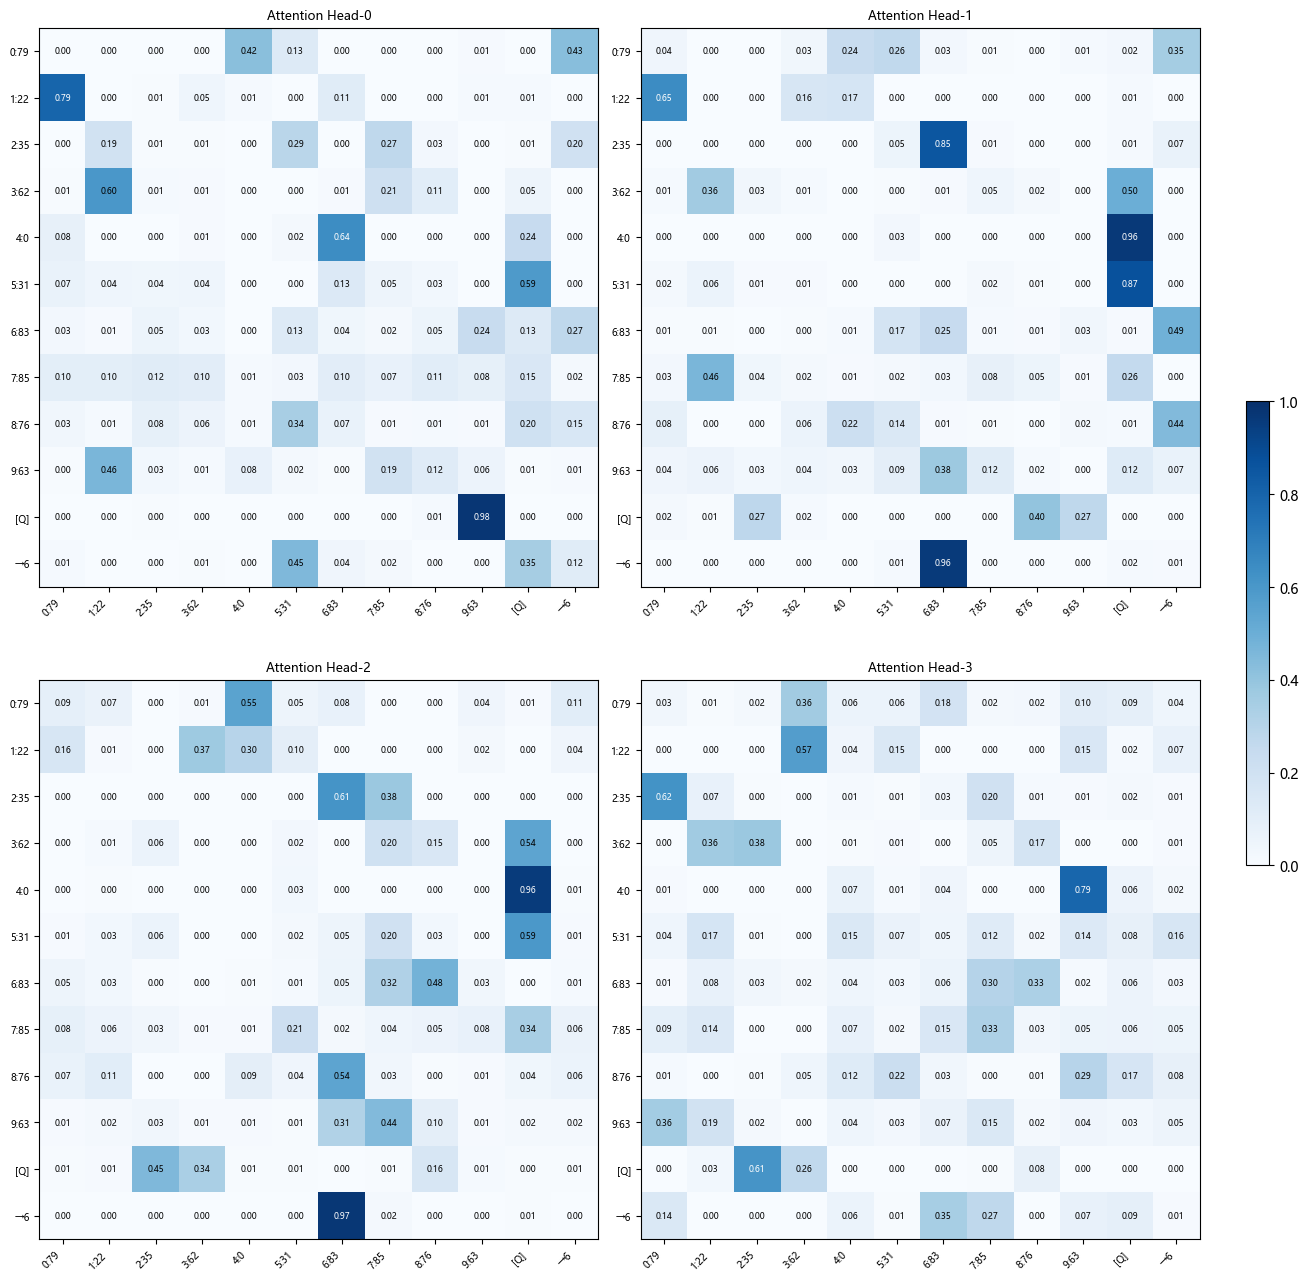

In [5]:
model.eval()
with torch.no_grad():
    eval_x, eval_y = get_seq_batch(4096, 10, 100)
    eval_logits = model(eval_x)[:, -1, :]   # (batch, 100)
    eval_pred = eval_logits.argmax(dim=-1)  # (batch,)

    y_true = eval_y.cpu().numpy()
    y_pred = eval_pred.cpu().numpy()

    print("Pointer Retrieval Classification Report")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    test_x, test_y = get_seq_batch(4, 10, 100)
    values = test_x[0, :10].tolist()
    q_idx = test_x[0, -1].item()
    query_labels = [f"{i}:{v}" for i, v in enumerate(values)] + ["[Q]", f"→{q_idx}"]

    pred = model(test_x)[:, -1, :]
    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : {pred[i].argmax(dim=-1).item()}")
        print(f"target: {test_y[i].item()}")
        print("-" * 30)

    plot_attention(model.attn_w[0], tokens=query_labels, title="Attention")

现在模型很轻易就学到了token间的位置关系, 成功避免了上一章实验2的情况, 这就是位置编码的必要性.